In [25]:
# 1. Problem Statement - Determine an employees decision to leave or stay at a company.

In [26]:
# 2. Data Cleaning

import numpy as np
import pandas as pd

# Load Dataset
df = pd.read_csv('Employee.csv')
df.head()

# Exploratory Data Analysis
df.shape
df.info()
df.describe()

# Null Values
df.isnull().sum()

# Duplicates
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


np.int64(1889)

In [27]:
# 3. Feature Engineering

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Categorial Variable Encoder
le =  LabelEncoder()
df = pd.get_dummies(df, columns=['Education'], drop_first=True)
df = pd.get_dummies(df, columns=['City'], drop_first=True)
df['Gender'] = le.fit_transform(df['Gender'])
df['EverBenched'] = le.fit_transform(df['EverBenched'])

# Features and Target Variables
X = df.drop('LeaveOrNot', axis=1)
y = df['LeaveOrNot']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
df.head()

,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune
0,2017,3,34,1,0,0,0,False,False,False,False
1,2013,1,28,0,0,3,1,False,False,False,True
2,2014,3,38,0,0,2,0,False,False,True,False
3,2016,3,27,1,0,5,1,True,False,False,False
4,2017,3,24,1,1,2,1,True,False,False,True


In [29]:
# 4. Models

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Random Forest Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
rf_pred = model.predict(X_test)

# Evaluations
print("Random Forest Acuracy:", accuracy_score(y_test, rf_pred ))
print()
print("Classification Report:",classification_report(y_test, rf_pred))
print()
cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:", cm)

# Feature Importance
feature_importance = model.feature_importances_
feature_importance = pd.DataFrame(feature_importance, index=X.columns, columns=['Importance'])
feature_importance

Random Forest Acuracy: 0.8506981740064447

Classification Report:               precision    recall  f1-score   support

           0       0.87      0.91      0.89       610
           1       0.82      0.73      0.77       321

    accuracy                           0.85       931
   macro avg       0.84      0.82      0.83       931
weighted avg       0.85      0.85      0.85       931


Confusion Matrix: [[558  52]
 [ 87 234]]


,Importance
JoiningYear,0.324044
PaymentTier,0.104675
Age,0.168651
Gender,0.093117
EverBenched,0.019962
ExperienceInCurrentDomain,0.089638
Education_Masters,0.075341
Education_PHD,0.011155
City_New Delhi,0.027900
City_Pune,0.085517


In [30]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
lr_pred = model.predict(X_test)

# Evaluations
print("Logisitic Regression Acuracy:", accuracy_score(y_test, lr_pred))
print()
print("Classification Report:", classification_report(y_test, lr_pred))
print()
cm = confusion_matrix(y_test, lr_pred)
print("Confusion Matrix:", cm)

Logisitic Regression Acuracy: 0.7443609022556391

Classification Report:               precision    recall  f1-score   support

           0       0.76      0.90      0.82       610
           1       0.70      0.45      0.55       321

    accuracy                           0.74       931
   macro avg       0.73      0.68      0.69       931
weighted avg       0.74      0.74      0.73       931


Confusion Matrix: [[548  62]
 [176 145]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision Tree Acuracy: 0.80343716433942

Classification Report:               precision    recall  f1-score   support

           0       0.80      0.94      0.86       610
           1       0.83      0.54      0.66       321

    accuracy                           0.80       931
   macro avg       0.81      0.74      0.76       931
weighted avg       0.81      0.80      0.79       931


Confusion Matrix: [[574  36]
 [147 174]]

Decision Tree


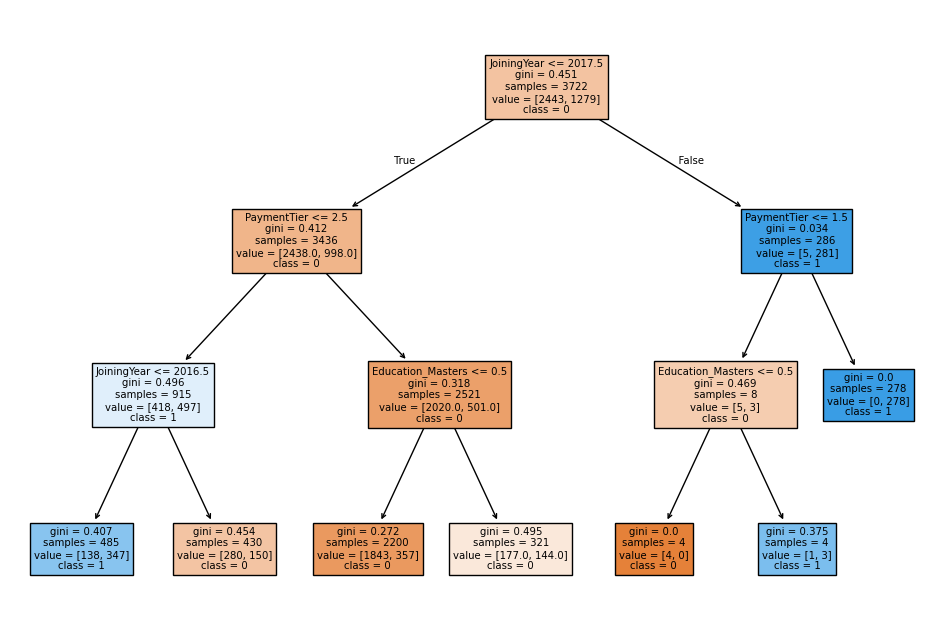

In [31]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(X_train, y_train)
dt_pred = clf.predict(X_test)

# Evaluations
print("Decision Tree Acuracy:", accuracy_score(y_test, dt_pred))
print()
print("Classification Report:", classification_report(y_test, dt_pred))
print()
cm = confusion_matrix(y_test, dt_pred)
print("Confusion Matrix:", cm)
print()

# Decision Tree
print("Decision Tree")
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['0', '1'])
plt.show()

In [32]:
# KNeighbors Classifier Model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Preiction
knn_pred = knn.predict(X_test)

# Evaluations
print("KNeighbors Acuracy:", accuracy_score(y_test, knn_pred))
print("Classification Report:", classification_report(y_test, knn_pred))
cm = confusion_matrix(y_test, knn_pred)
print("Confusions Matrix:", cm)

KNeighbors Acuracy: 0.790547798066595
Classification Report:               precision    recall  f1-score   support

           0       0.82      0.88      0.85       610
           1       0.73      0.62      0.67       321

    accuracy                           0.79       931
   macro avg       0.77      0.75      0.76       931
weighted avg       0.79      0.79      0.79       931

Confusions Matrix: [[536  74]
 [121 200]]


In [33]:
# 5. Results

# Random Forest Acuracy: 0.8506981740064447
# Logisitic Regression Acuracy: 0.7443609022556391
# Decision Tree Acuracy: 0.8506981740064447
# KNeighbors Acuracy: 0.7443609022556391

# Employees that joined after 2016 with a 2.5 payment or less would leave the company
# Employees that joined after 2017 with a 1.5 payment or less would leave the company
# Employees that joined after 2017 with a 1.5 payment or less and city wasn't New Delhi would leave the company

# Employees with an education leavel less than a masters degree would not leave the company